# Importações

In [1]:
from utils.common import import_dataframe

from utils.common import seasonal_plot, plot_periodogram
from utils.common import plot_lags, make_lags, make_leads, make_multistep_target

from utils.common import print_equation, plot_params, plot_linear_model
from utils.common import calculate_metrics

from utils.common import ModeloPrevisaoVolume
from utils.common import HybridDirect, HybridRecursive, HybridDirRec, HybridBase
from utils.common import plot_plotly, plot_multistep_plotly

from utils.common import get_model_name
from utils.common import highlight_val_only
from utils.common import rodar_treino_volume_kfold
from utils.common import rodar_treino_volume_view

import pandas as pd
import numpy as np
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso, Ridge
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
import warnings
warnings.filterwarnings("ignore")

# Volume

In [2]:
nome_coluna_volume = "Volume Útil Armazenado (%)"
nome_coluna_vazao_natural = "Vazão Natural (m³/s)"
nome_coluna_vazao_jusante = "Vazão Jusante (m³/s)"
df = import_dataframe()

df_volume = df[["Data", nome_coluna_volume]].copy()
df_vazao_natural = df[["Data", nome_coluna_vazao_natural]].copy()
df_vazao_jusante = df[["Data", nome_coluna_vazao_jusante]].copy()

df_volume = df_volume.set_index("Data")
df_vazao_natural = df_vazao_natural.set_index("Data")
df_vazao_jusante = df_vazao_jusante.set_index("Data")

df_volume_series = (
  df_volume
    .groupby('Data').mean()
    .squeeze()
)

df_vazao_natural_series = (
  df_vazao_natural
    .groupby('Data').mean()
    .squeeze()
)

df_vazao_jusante_series = (
  df_vazao_jusante
    .groupby('Data').mean()
    .squeeze()
)

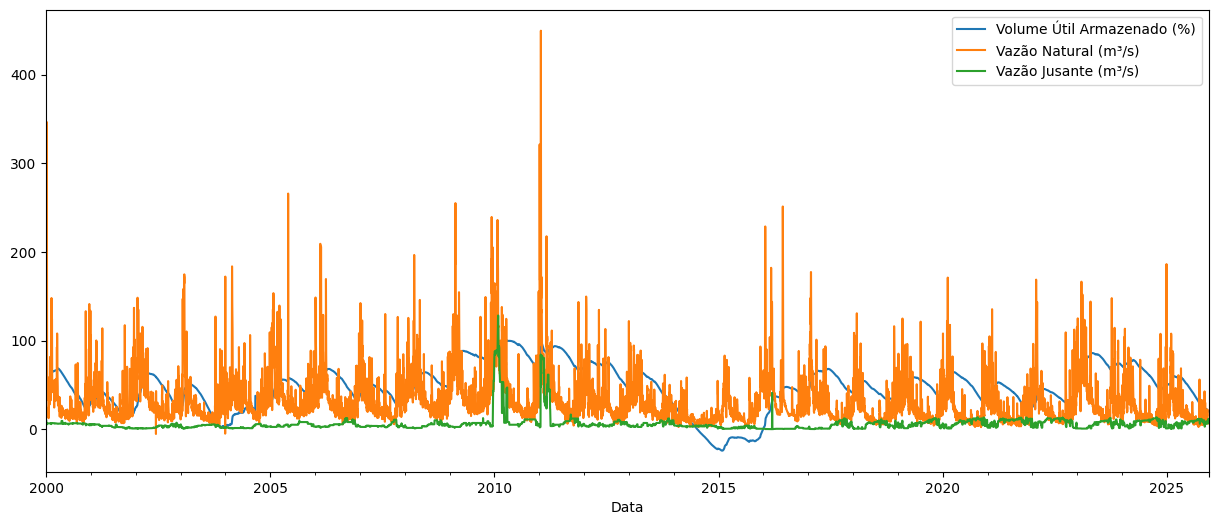

In [3]:
df_plot_vol = df[["Data", nome_coluna_volume]].copy()
df_plot_vn = df[["Data", nome_coluna_vazao_natural]].copy()
df_plot_vj = df[["Data", nome_coluna_vazao_jusante]].copy()

df_plot_vol = df_plot_vol.set_index("Data")
df_plot_vn = df_plot_vn.set_index("Data")
df_plot_vj = df_plot_vj.set_index("Data")

plot_params = {
  'color': '0.75',
  'style': '.-',
  'markeredgecolor': '0.25',
  'markerfacecolor': '0.25',
  'legend': False
}

ax = df_plot_vol.plot(style='-', markeredgecolor='0.25', markerfacecolor='0.25', legend=False)
ax = df_plot_vn.plot(ax=ax, legend=False)
ax = df_plot_vj.plot(ax=ax, legend=False)
ax.legend()

## Verificar estacionariedade

In [4]:
from statsmodels.tsa.stattools import adfuller, kpss

def adf_test(timeseries):
  print("Results of Dickey-Fuller Test:")
  dftest = adfuller(timeseries, autolag="AIC")
  dfoutput = pd.Series(
    dftest[0:4],
    index=[
      "Test Statistic",
      "p-value",
      "#Lags Used",
      "Number of Observations Used",
    ],
  )
  for key, value in dftest[4].items():
    dfoutput["Critical Value (%s)" % key] = value
  print(dfoutput)

def kpss_test(timeseries):
  print("Results of KPSS Test:")
  kpsstest = kpss(timeseries, regression="c", nlags="auto")
  kpss_output = pd.Series(
    kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
  )
  for key, value in kpsstest[3].items():
    kpss_output["Critical Value (%s)" % key] = value
  print(kpss_output)

In [5]:
print("*"*80)
adf_test(df_plot_vol)
print("*"*80)
kpss_test(df_plot_vol)
print("*"*80)

********************************************************************************
Results of Dickey-Fuller Test:
Test Statistic                   -3.661611
p-value                           0.004687
#Lags Used                       38.000000
Number of Observations Used    9433.000000
Critical Value (1%)              -3.431043
Critical Value (5%)              -2.861846
Critical Value (10%)             -2.566933
dtype: float64
********************************************************************************
Results of KPSS Test:
Test Statistic            0.665860
p-value                   0.016649
Lags Used                58.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64
********************************************************************************


- O primeiro teste (ADF) teve resultado p-value menor que 0,05. Esse teste sugere que a série é estacionária.
- O segundo teste (KPSS) teve resultado p-value menor que 0,05. Esse teste sugere não ser estacionária.
- Testes inconclusivos.

## Análise de Sazonalidade

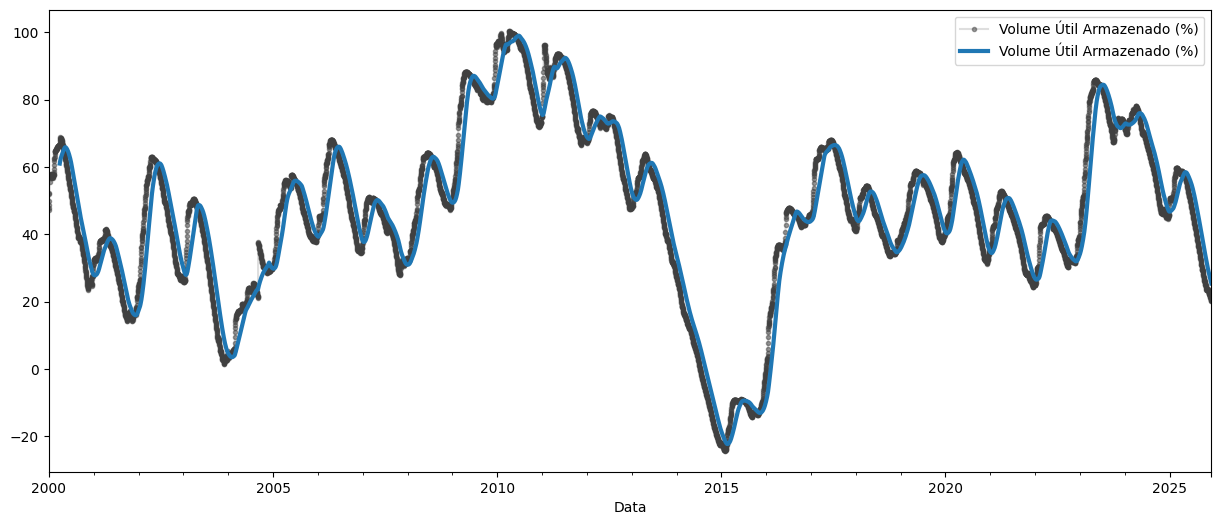

In [6]:
y = df_volume.copy()
trend = y.rolling(
  window=90,
).mean()

ax = y.plot(**plot_params, alpha=0.5)
ax = trend.plot(ax=ax, linewidth=3)
ax.legend()

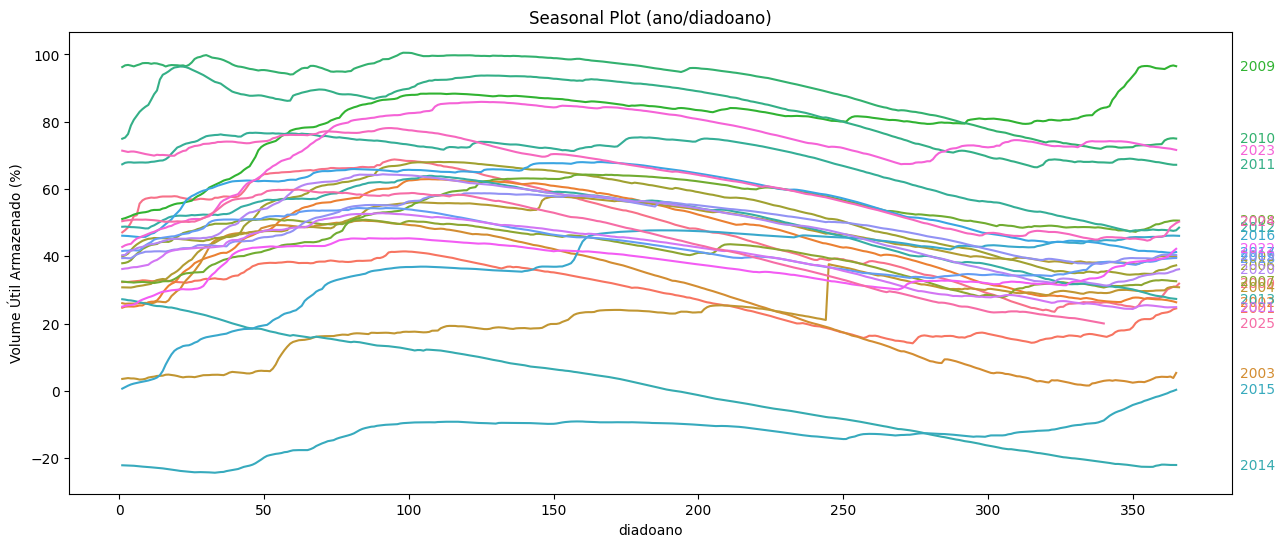

In [7]:
X = df_volume.copy()
X["ano"] = X.index.year
X["diadoano"] = X.index.dayofyear
seasonal_plot(X, y=nome_coluna_volume, period='ano', freq='diadoano');

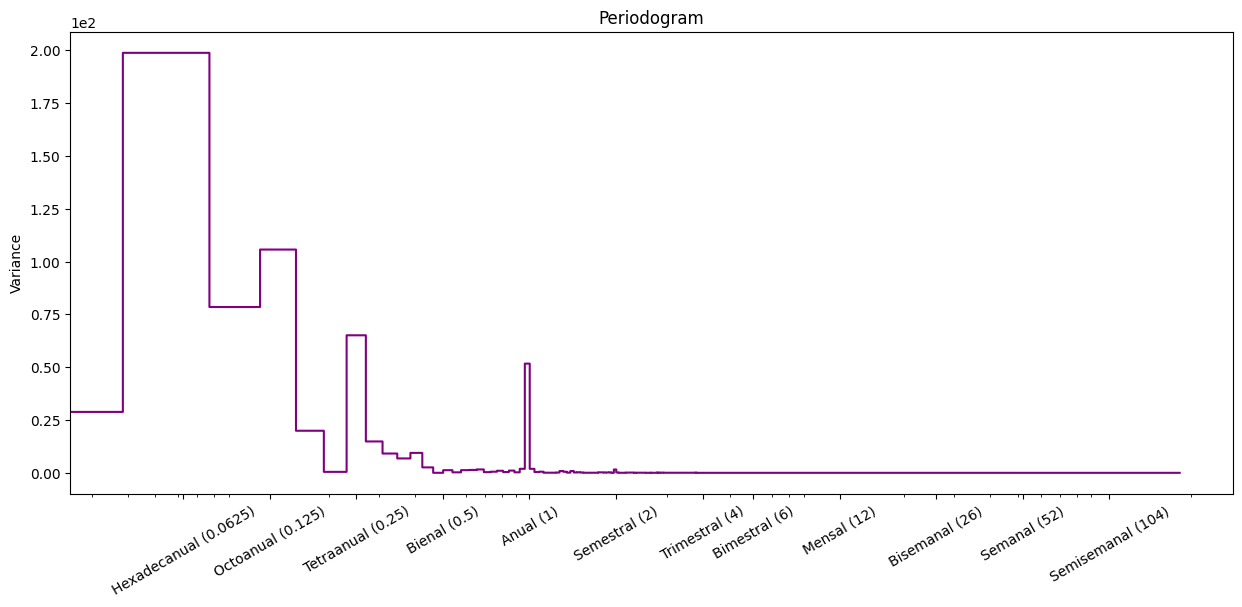

In [8]:
plot_periodogram(df_volume_series);

## Sazonalidade a partir de 2018

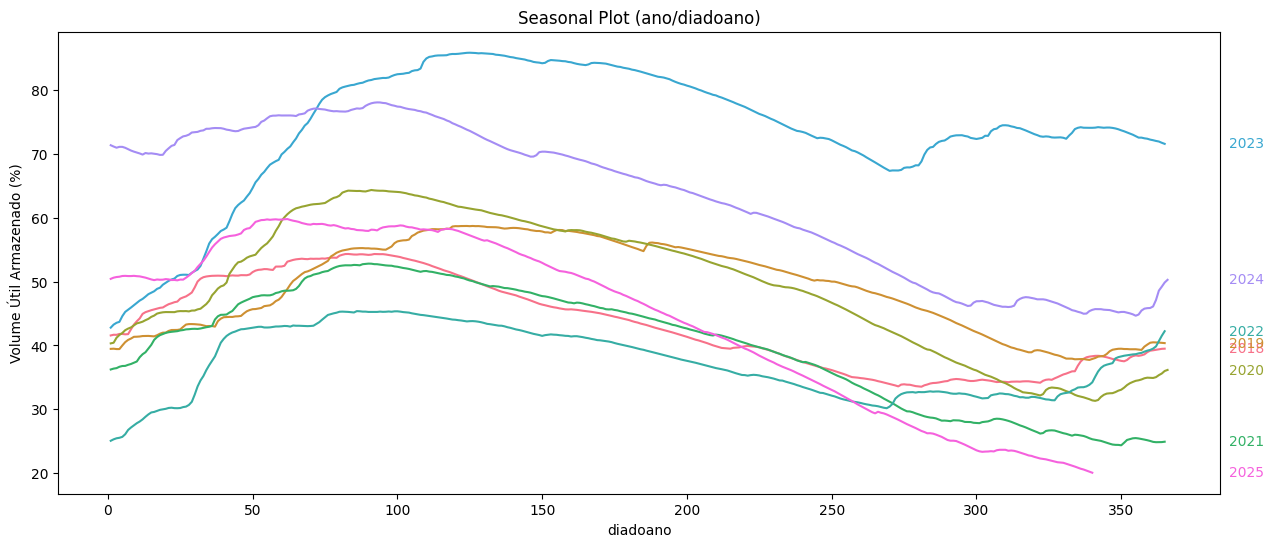

In [9]:
df_volume_recente = df_volume[df_volume.index >= "2018-01-01"].copy()
X = df_volume_recente.copy()
X["ano"] = X.index.year
X["diadoano"] = X.index.dayofyear
seasonal_plot(X, y=nome_coluna_volume, period='ano', freq='diadoano');

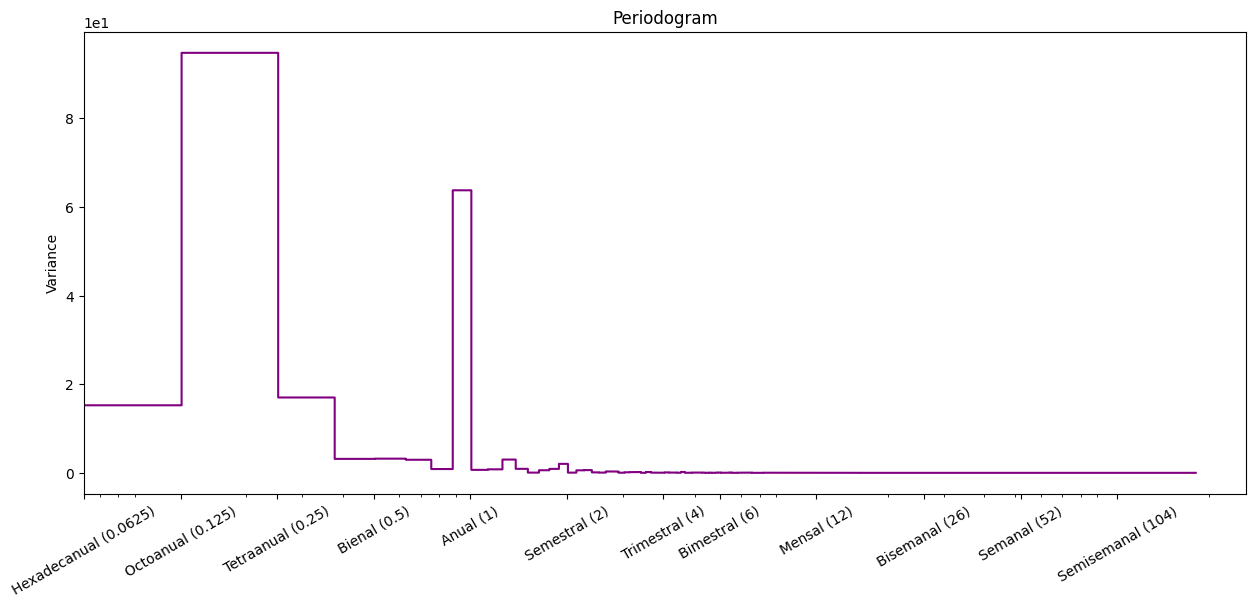

In [10]:
df_volume_recente_series = (
  df_volume_recente
    .groupby('Data').mean()
    .squeeze()
)
plot_periodogram(df_volume_recente_series);

# Ciclos

## Autocorrelação Parcial e Gráfico de Defasagem

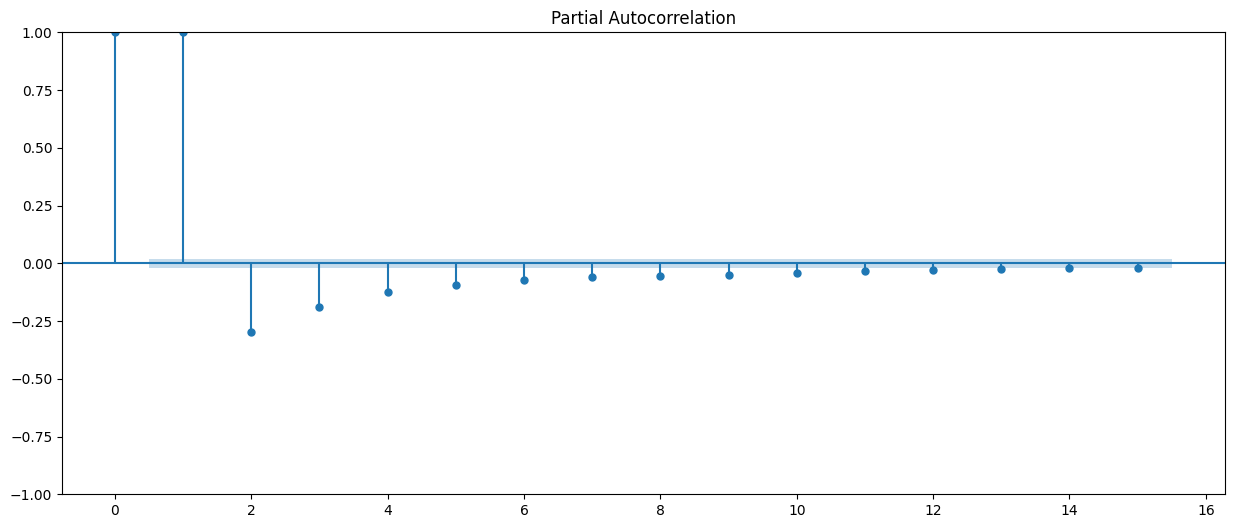

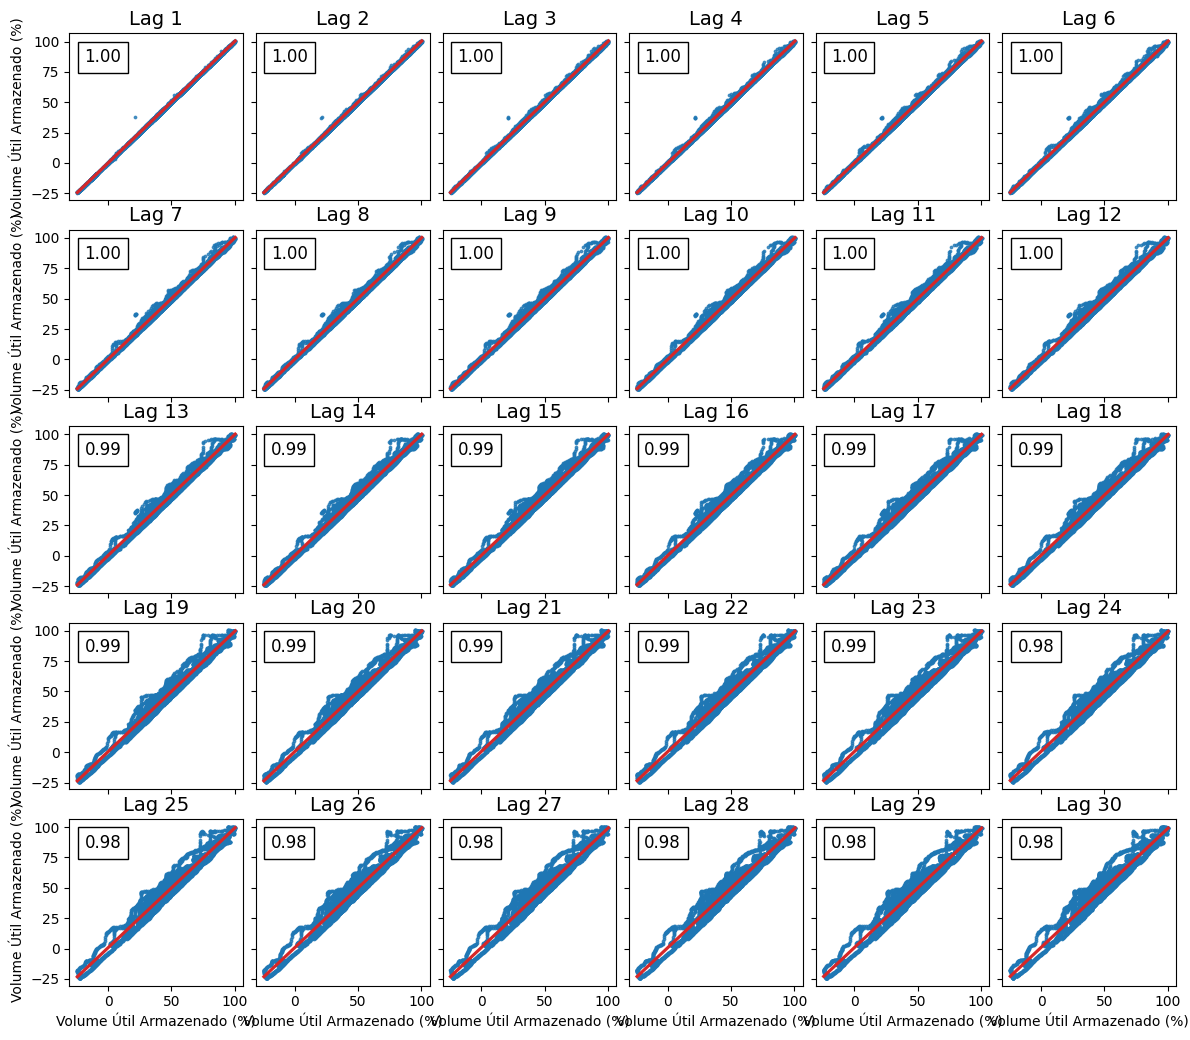

In [11]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df_volume_series, lags=15);
plot_lags(df_volume_series, lags=30, nrows=5);

# Modelagem

- Lags para Volume
- Leads para Vazão Natural e Jusante.

In [12]:
X_lags = make_lags(df_volume.squeeze(), 1)
X_Qin_leads = make_leads(df_vazao_natural.squeeze(), 1, name="Qin")
X_Qout_leads = make_leads(df_vazao_jusante.squeeze(), 1, name="Qout")

X_full = pd.concat([X_lags, X_Qin_leads, X_Qout_leads], axis=1).dropna()
display(X_full)

,y_lag_1,Qin_lead_0,Qout_lead_0
Data,,,
2000-01-02,47.11254,94.864,10.18
2000-01-03,47.77519,108.208,7.29
2000-01-04,48.59438,162.936,6.34
2000-01-05,49.99680,211.604,6.33
2000-01-06,51.94578,59.722,5.40
...,...,...,...
2025-12-02,20.83241,10.243,8.35
2025-12-03,20.66146,11.494,8.35
2025-12-04,20.53750,11.024,11.60


In [13]:
VALIDATION_SIZE = 1*365
PREDICTION_SIZE = 90

y = df_volume_series.copy()
y, X_full = y.align(X_full, join='inner')

y_multistep_target = make_multistep_target(y, steps=PREDICTION_SIZE).dropna()
y_multistep_target, X = y_multistep_target.align(X_full, join='inner', axis=0)

X_train, X_valid, y_train, y_valid = train_test_split(X, y_multistep_target, test_size=VALIDATION_SIZE, shuffle=False)
X_train_rec, X_valid_rec, y_train_rec, y_valid_rec = train_test_split(X_full, y, test_size=VALIDATION_SIZE, shuffle=False)

In [14]:
dummy = DummyRegressor(strategy="constant", constant=0)

model1 = HybridRecursive(LinearRegression(fit_intercept=False), dummy, lags=1)
model1.fit(X_train_rec, y_train_rec)
model1.calculate_lags(X_valid_rec)

y_fit = model1.predict(X_train_rec)
y_pred = model1.predict(X_valid_rec)

metric = calculate_metrics(
  y.loc[y_fit.index],
  y.loc[y_pred.index],
  y_fit.squeeze(),
  y_pred.squeeze()
)
display(metric)

fig1 = plot_plotly(
  y.loc[y_fit.index],
  y_fit,
  title="Forecast - Treino",
  showlegend=True
)

fig2 = plot_plotly(
  y.loc[y_pred.index],
  y_pred,
  title="Forecast - Validação",
  showlegend=True
)

,RMSE,MAE
Treino,0.204391,0.084449
Validação,0.063035,0.053972


9574736


58391306


In [15]:
eq_text = f"y = {model1.trend_model.intercept_:.5f} + "
eq_text += " + ".join([f"{c:.5f}·X{i+1}" for i, c in enumerate(model1.trend_model.coef_[0])])
print(eq_text)

y = 0.00000 + 0.99646·X1 + 0.00790·X2 + -0.00828·X3


### Resultado

- Nesta primeira modelagem, o modelo tem por entrada o lag da variável Volume (modelo autoregressivo) e valores de lead para vazão de entrada e vazão de saída.
- Em um cenário real de predição, é necessário prever as vazões e utilizar a primeira previsão de volume como entrada para as próximas.
- Na próxima etapa, pretende-se implementar esta abordagem.


## Seleção de features

### Features para Vazão Natural

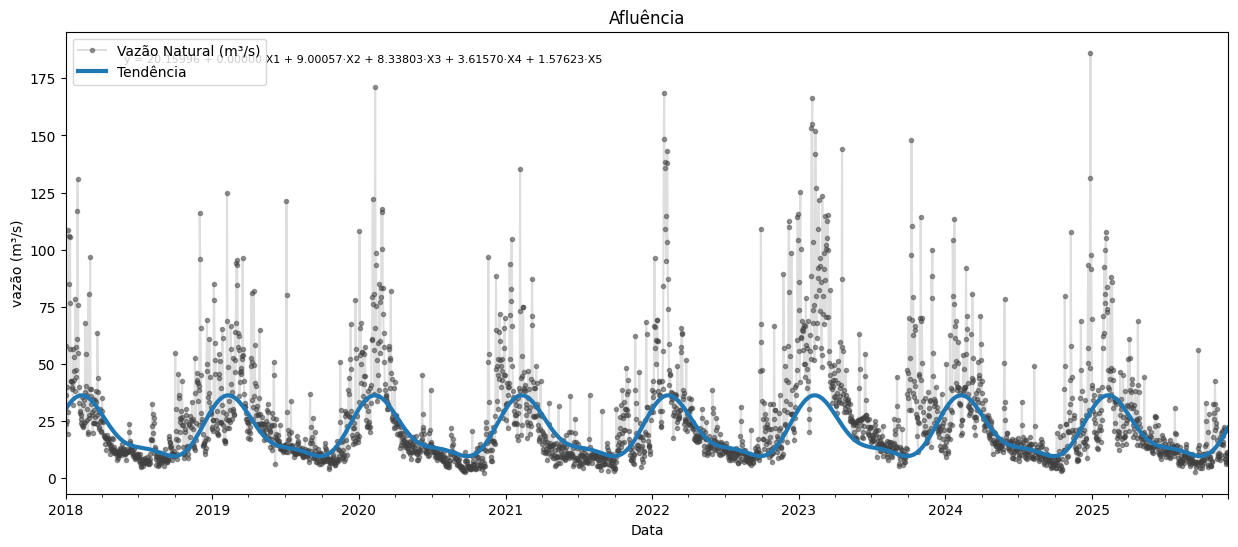

In [16]:
percentil_escolhido = 0.3
y_vn_median = df_vazao_natural_series.copy()

df = y_vn_median.to_frame().copy()
df["mmdd"] = df.index.strftime("%m-%d")
mins = df.groupby("mmdd")[nome_coluna_vazao_natural].quantile(percentil_escolhido)
df["valor_transformado"] = df["mmdd"].map(mins)
y_vn_median = df["valor_transformado"]
y_vn_median = y_vn_median[y_vn_median.index >= "2018-01-01"]
y_vn_median.name = nome_coluna_vazao_natural

y_vn = y_vn_median.copy()
y_vn_real = df_vazao_natural_series[df_vazao_natural_series.index >= "2018-01-01"].copy()

fourier = CalendarFourier(freq="Y", order=2)
dp = DeterministicProcess(
  index=y_vn.index,
  constant=False,
  order=1,
  seasonal=False,
  additional_terms=[fourier],
  drop=True,
)
X = dp.in_sample()

model_sazonal = LinearRegression().fit(X, y_vn)
y_pred = pd.Series(
  model_sazonal.predict(X),
  index=X.index,
  name='Fitted',
)

plot_linear_model(model_sazonal, X, y_vn_real)

In [17]:
y_vn_median = df_vazao_natural_series.copy()

df = y_vn_median.to_frame().copy()
df["mmdd"] = df.index.strftime("%m-%d")
mins = df.groupby("mmdd")[nome_coluna_vazao_natural].quantile(percentil_escolhido)
df["valor_transformado"] = df["mmdd"].map(mins)
y_vn_median = df["valor_transformado"]
y_vn_median = y_vn_median[y_vn_median.index >= "2018-01-01"]
y_vn_median.name = nome_coluna_vazao_natural

y_vn = y_vn_median.copy()
y_vn = df_vazao_natural_series[df_vazao_natural_series.index >= "2018-01-01"].copy()
#upper = y_vn.quantile(0.80)
#lower = y_vn.quantile(0.00)
#y_vn = y_vn.clip(lower, upper)

fourier = CalendarFourier(freq="Y", order=2)
dp = DeterministicProcess(
  index=y_vn.index,
  constant=False,
  order=1,
  seasonal=False,
  additional_terms=[fourier],
  drop=True,
)
X_full_vn = dp.in_sample()

VALIDATION_SIZE = 1*365
PREDICTION_SIZE = 90

y_vn_multistep_target = make_multistep_target(y_vn, steps=PREDICTION_SIZE).dropna()
y_vn_multistep_target, X_vn = y_vn_multistep_target.align(X_full_vn, join='inner', axis=0)

X_vn_train, X_vn_valid, y_vn_train, y_vn_valid = train_test_split(X_vn, y_vn_multistep_target, test_size=VALIDATION_SIZE, shuffle=False)
X_vn_train_rec, X_vn_valid_rec, y_vn_train_rec, y_vn_valid_rec = train_test_split(X_full_vn, y_vn, test_size=VALIDATION_SIZE, shuffle=False)

### Features para Vazão Jusante

In [18]:
y_vj = df_vazao_jusante_series[df_vazao_jusante_series.index >= "2018-01-01"].copy()

fourier = CalendarFourier(freq="Y", order=2)
dp = DeterministicProcess(
  index=y_vj.index,
  constant=False,
  order=1,
  seasonal=False,
  additional_terms=[fourier],
  drop=True,
)
X_full_vj = dp.in_sample()

y_vj_multistep_target = make_multistep_target(y_vj, steps=PREDICTION_SIZE).dropna()
y_vj_multistep_target, X_vj = y_vj_multistep_target.align(X_full_vj, join='inner', axis=0)

X_vj_train, X_vj_valid, y_vj_train, y_vj_valid = train_test_split(X_vj, y_vj_multistep_target, test_size=VALIDATION_SIZE, shuffle=False)
X_vj_train_rec, X_vj_valid_rec, y_vj_train_rec, y_vj_valid_rec = train_test_split(X_full_vj, y_vj, test_size=VALIDATION_SIZE, shuffle=False)

### Features para Volume

In [19]:
def get_train_test_split_recursive():
  y_vol = df_volume_series[df_volume_series.index >= "2018-01-01"].copy()
  X_lags = make_lags(y_vol.squeeze(), 1)
  X_Qin_leads = make_leads(y_vn.squeeze(), 1, name="Qin")
  X_Qout_leads = make_leads(y_vj.squeeze(), 1, name="Qout")
  X_full_vol = pd.concat([X_lags, X_Qin_leads, X_Qout_leads], axis=1).dropna()

  y_vol, X_full_vol = y_vol.align(X_full_vol, join='inner', axis=0)

  X_vol_train_rec, X_vol_valid_rec, y_vol_train_rec, y_vol_valid_rec = train_test_split(X_full_vol, y_vol, test_size=VALIDATION_SIZE, shuffle=False)
  return y_vol, X_vol_train_rec, X_vol_valid_rec, y_vol_train_rec, y_vol_valid_rec

def get_train_test_split_direct():
  y_vol = df_volume_series[df_volume_series.index >= "2018-01-01"].copy()
  X_lags = make_lags(y_vol.squeeze(), 1)
  X_Qin_leads = make_leads(y_vn.squeeze(), 90, name="Qin")
  X_Qout_leads = make_leads(y_vj.squeeze(), 90, name="Qout")
  X_full_vol = pd.concat([X_lags, X_Qin_leads, X_Qout_leads], axis=1).dropna()

  y_vol, X_full_vol = y_vol.align(X_full_vol, join='inner', axis=0)

  y_vol_multistep_target = make_multistep_target(y_vol, steps=PREDICTION_SIZE)
  y_vol_multistep_target, X_vol = y_vol_multistep_target.align(X_full_vol, join='inner', axis=0)

  X_vol_train, X_vol_valid, y_vol_train, y_vol_valid = train_test_split(X_vol, y_vol_multistep_target, test_size=VALIDATION_SIZE, shuffle=False)
  return y_vol_multistep_target, X_vol_train, X_vol_valid, y_vol_train, y_vol_valid

y_vol_rec, X_vol_train_rec, X_vol_valid_rec, y_vol_train_rec, y_vol_valid_rec = get_train_test_split_recursive()
y_vol_dir, X_vol_train, X_vol_valid, y_vol_train, y_vol_valid = get_train_test_split_direct()

# Modelagem

## Estratégia Recursiva

### Sem vazão jusante

In [20]:
model = ModeloPrevisaoVolume(
  base_model = LinearRegression(fit_intercept=False),
  usar_jusante = False,
)

model.fit_vazao_natural(X_vn_train_rec, y_vn_train_rec)
#model.fit_vazao_jusante(X_vj_train_rec, y_vj_train_rec)
model.calculate_lags(X_vn_valid_rec)
model.fit(X_vol_train_rec, y_vol_train_rec)

X_vn_train_rec_drop = X_vn_train_rec.iloc[1:]
y_fit = model.predict(X_vn_train_rec_drop)
y_pred = model.predict(X_vn_valid_rec)

metric = calculate_metrics(
  y_vol_rec.loc[y_fit.index],
  y_vol_rec.loc[y_pred.index],
  y_fit.squeeze(),
  y_pred.squeeze()
)
display(metric)

fig1 = plot_plotly(
  y_vol_rec.loc[y_fit.index],
  y_fit,
  title="Forecast - Treino",
  showlegend=True
)

fig2 = plot_plotly(
  y_vol_rec.loc[y_pred.index],
  y_pred,
  title="Forecast - Validação",
  showlegend=True
)

,RMSE,MAE
Treino,0.059751,0.046525
Validação,19.713215,16.092366


71414142


82396602


### Com vazão jusante

In [21]:
model = ModeloPrevisaoVolume(
  base_model = LinearRegression(fit_intercept=False),
  usar_jusante = True,
)

model.fit_vazao_natural(X_vn_train_rec, y_vn_train_rec)
model.fit_vazao_jusante(X_vj_train_rec, y_vj_train_rec)
model.calculate_lags(X_vn_valid_rec)
model.fit(X_vol_train_rec, y_vol_train_rec)

X_vn_train_rec_drop = X_vn_train_rec.iloc[1:]
y_fit = model.predict(X_vn_train_rec_drop)
y_pred = model.predict(X_vn_valid_rec)

metric = calculate_metrics(
  y_vol_rec.loc[y_fit.index],
  y_vol_rec.loc[y_pred.index],
  y_fit.squeeze(),
  y_pred.squeeze()
)
display(metric)

fig1 = plot_plotly(
  y_vol_rec.loc[y_fit.index],
  y_fit,
  title="Forecast - Treino",
  showlegend=True
)

fig2 = plot_plotly(
  y_vol_rec.loc[y_pred.index],
  y_pred,
  title="Forecast - Validação",
  showlegend=True
)

,RMSE,MAE
Treino,0.037870,0.031224
Validação,17.627047,14.807092


73015551


68094411


# Testando outros modelos

In [22]:
results_rec = []

y_vol = df_volume_series[df_volume_series.index >= "2018-01-01"].copy()
X_lags = make_lags(y_vol.squeeze(), 1)
X_Qin_leads = make_leads(y_vn.squeeze(), 1, name="Qin")
X_Qout_leads = make_leads(y_vj.squeeze(), 1, name="Qout")
X_full_vol = pd.concat([X_lags, X_Qin_leads, X_Qout_leads], axis=1).dropna()

y_vol, X_full_vol = y_vol.align(X_full_vol, join='inner', axis=0)

dados = {
  "X_vol_rec": X_full_vol,
  "y_vol_rec": y_vol,
  "X_vn_rec": X_full_vn.loc[X_full_vol.index],
  "y_vn_rec": y_vn.loc[X_full_vol.index],
  "X_vj_rec": X_full_vj.loc[X_full_vol.index],
  "y_vj_rec": y_vj.loc[X_full_vol.index],
}

N_SPLITS = 5
FORECAST_HORIZON = 90
tscv = TimeSeriesSplit(
  n_splits=N_SPLITS,
  test_size=FORECAST_HORIZON,
  gap=0
)

In [23]:
# ElasticNet/LinearRegression
model_vn_rec_folds = [
  HybridRecursive(ElasticNet(), LinearRegression(), lags=2)
    for _ in range(N_SPLITS)
]
# LinearRegression/LinearRegression
model_vj_rec_folds = [
  HybridRecursive(LinearRegression(), LinearRegression(), lags=2)
    for _ in range(N_SPLITS)
]

for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(dados["X_vn_rec"])):
  X_vn_train_fold = dados["X_vn_rec"].iloc[train_idx]
  X_vn_test_fold = dados["X_vn_rec"].iloc[test_idx]
  y_vn_train_fold = dados["y_vn_rec"].iloc[train_idx]
  #y_vn_test_fold = dados["y_vn_rec"].iloc[test_idx]

  X_vj_train_fold = dados["X_vj_rec"].iloc[train_idx]
  X_vj_test_fold = dados["X_vj_rec"].iloc[test_idx]
  y_vj_train_fold = dados["y_vj_rec"].iloc[train_idx]
  #y_vj_test_fold = dados["y_vj_rec"].iloc[test_idx]
  
  model_vn_rec_folds[fold_idx].fit(X_vn_train_fold, y_vn_train_fold)
  model_vn_rec_folds[fold_idx].calculate_lags(X_vn_test_fold)
  model_vj_rec_folds[fold_idx].fit(X_vj_train_fold, y_vj_train_fold)
  model_vj_rec_folds[fold_idx].calculate_lags(X_vj_test_fold)

In [24]:

modelos_treino = [LinearRegression(fit_intercept=False), ElasticNet(), Lasso(), Ridge(), XGBRegressor(), MLPRegressor()]

for modelo in modelos_treino:
  nome_modelo = get_model_name(modelo)
  print("*"*90)
  print("Modelo Volume:", nome_modelo)

  rodar_treino_volume_kfold(
    model_name = nome_modelo,
    model_base_volume = modelo,
    model_vn_folds = model_vn_rec_folds,
    model_vj_folds = model_vj_rec_folds,
    splitter = tscv,
    results_array= results_rec,
    dados = dados
  )

******************************************************************************************
Modelo Volume: LinearRegression
******************************************************************************************
Modelo Volume: ElasticNet
******************************************************************************************
Modelo Volume: Lasso
******************************************************************************************
Modelo Volume: Ridge
******************************************************************************************
Modelo Volume: XGBRegressor
******************************************************************************************
Modelo Volume: MLPRegressor


## Resultados

- Estratégia recursiva com vazão jusante.

### Estratégia Recursiva

In [25]:
result_df = pd.concat(results_rec)
result_df.columns = [f"{metric}_{stat}" for metric, stat in result_df.columns]

styled = (
  result_df.style
  .apply(highlight_val_only, subset=[
    'RMSE_mean', 'RMSE_std', 'RMSE_min', 'RMSE_max',
    'MAE_mean', 'MAE_std', 'MAE_min', 'MAE_max'])
  .format("{:.4f}")
)
display(styled)

### Resultado Linear

In [26]:
dados2 = {
  "df_volume_series": df_volume_series,
  "y_vn": y_vn,
  "y_vj": y_vj,
  "X_full_vn": X_full_vn,
  "X_full_vj": X_full_vj,
  "y_vol_rec": y_vol_rec
}

# ElasticNet/LinearRegression
model_vn = HybridRecursive(ElasticNet(), LinearRegression(), lags=2)
# LinearRegression/LinearRegression
model_vj = HybridRecursive(LinearRegression(), LinearRegression(), lags=2)

rodar_treino_volume_view(
  LinearRegression(fit_intercept=False),
  model_vn,
  model_vj,
  dados=dados2,
  VALIDATION_SIZE=90
)

43811227


17443588


### Resultado Ridge

In [29]:
# ElasticNet/LinearRegression
model_vn = HybridRecursive(ElasticNet(), LinearRegression(), lags=2)
# LinearRegression/LinearRegression
model_vj = HybridRecursive(LinearRegression(), LinearRegression(), lags=2)

rodar_treino_volume_view(
  Ridge(),
  model_vn,
  model_vj,
  dados=dados2,
  VALIDATION_SIZE=90
)

74815053


91501957


### Resultado MLPRegressor

In [27]:
# ElasticNet/LinearRegression
model_vn = HybridRecursive(ElasticNet(), LinearRegression(), lags=2)
# LinearRegression/LinearRegression
model_vj = HybridRecursive(LinearRegression(), LinearRegression(), lags=2)

rodar_treino_volume_view(
  MLPRegressor(),
  model_vn,
  model_vj,
  dados=dados2,
  VALIDATION_SIZE=90
)

38481116


71374693


# Resultado por fold:

In [35]:
indices = dados['X_vn_rec'].index
train_idx, test_idx = train_test_split(indices, test_size=VALIDATION_SIZE, shuffle=False)

# ElasticNet/LinearRegression
model_vn = HybridRecursive(ElasticNet(), LinearRegression(), lags=2)
# LinearRegression/LinearRegression
model_vj = HybridRecursive(LinearRegression(), LinearRegression(), lags=2)

X_vn_train_fold = dados["X_vn_rec"].loc[train_idx]
X_vn_test_fold = dados["X_vn_rec"].loc[test_idx]
y_vn_train_fold = dados["y_vn_rec"].loc[train_idx]
#y_vn_test_fold = dados["y_vn_rec"].loc[test_idx]
X_vj_train_fold = dados["X_vj_rec"].loc[train_idx]
X_vj_test_fold = dados["X_vj_rec"].loc[test_idx]
y_vj_train_fold = dados["y_vj_rec"].loc[train_idx]
#y_vj_test_fold = dados["y_vj_rec"].loc[test_idx]

model_vn.fit(X_vn_train_fold, y_vn_train_fold)
model_vn.calculate_lags(X_vn_test_fold)
model_vj.fit(X_vj_train_fold, y_vj_train_fold)
model_vj.calculate_lags(X_vj_test_fold)

model_vn_rec_folds = [
  model_vn for _ in range(N_SPLITS)
]
model_vj_rec_folds = [
  model_vj for _ in range(N_SPLITS)
]

"""
# LinearRegression(fit_intercept=False)
# Ridge()
# MLPRegressor()

  MLPRegressor(
    hidden_layer_sizes=(100),
    activation='relu',
    solver='adam',
    learning_rate_init=1e-4,
    max_iter=2000,
    tol=1e-4,
    early_stopping=False,
  ),
"""
rodar_treino_volume_kfold(
  model_name = 'Final',
  model_base_volume = MLPRegressor(
    hidden_layer_sizes=(100),
    activation='relu',
    solver='adam',
    learning_rate_init=1e-4,
    max_iter=3000,
    tol=1e-4,
    early_stopping=False,
  ),
  model_vn_folds = model_vn_rec_folds,
  model_vj_folds = model_vj_rec_folds,
  splitter = tscv,
  results_array = [],
  dados = dados,
  plot = True
)

91326548


49500230


1253188


69905067


12422422


RMSE                                      MAE            \
                      mean       std       min        max      mean       std   
Modelo Dados                                                                    
Final  Treino     0.119485  0.010804  0.103923   0.131618  0.070758  0.011086   
       Validação  7.414951  4.783552  2.918284  14.775847  6.453050  4.206029   

                                       
                       min        max  
Modelo Dados                           
Final  Treino     0.063484   0.090215  
       Validação  2.335188  12.774523